In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
           "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
           "hours-per-week", "native-country", "income"]


data = pd.read_csv(url, names=columns, sep=',\s', na_values=["?"], engine='python')

In [ ]:
data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
data.shape

(32561, 15)

In [ ]:
# Initial data exploration
print(data.head())
print(data.info())
print(data.describe())


   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0             0             

In [ ]:
# Drop irrelevant features
data = data.drop(['fnlwgt', 'education-num'], axis=1)

In [ ]:
# Handle missing values
data = data.dropna()

In [ ]:
# Convert categorical features to numerical values
categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']
le = LabelEncoder()

for feature in categorical_features:
    data[feature] = le.fit_transform(data[feature])


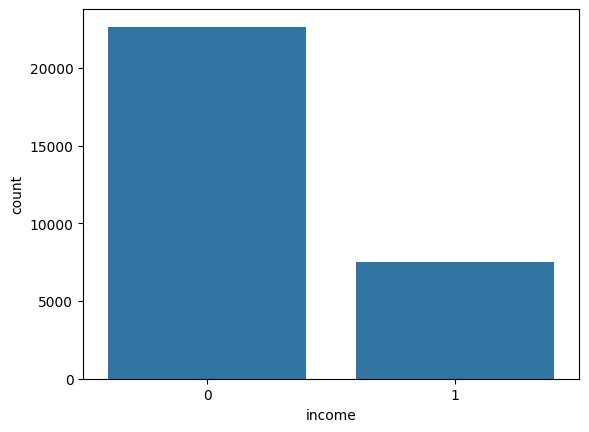

In [ ]:
# Visualize the count of income distribution
sns.countplot(x='income', data=data)
plt.show()


In [ ]:
# Split the dataset into training and testing sets
X = data.drop('income', axis=1)
y = data['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Standardize the continuous features for Gaussian Naive Bayes
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Initialize and train the Gaussian Naive Bayes model
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

GaussianNB()

In [ ]:
# Predict and evaluate the Gaussian Naive Bayes model
y_pred_gnb = gnb.predict(X_test_scaled)
y_pred_proba_gnb = gnb.predict_proba(X_test)[:, 1]
print("Gaussian Naive Bayes Model")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gnb)}")
cm = confusion_matrix(y_test, y_pred_gnb)
print(cm)
print(classification_report(y_test, y_pred_gnb))


Gaussian Naive Bayes Model
Accuracy: 0.793966517487154
[[4299  204]
 [1039  491]]
              precision    recall  f1-score   support

           0       0.81      0.95      0.87      4503
           1       0.71      0.32      0.44      1530

    accuracy                           0.79      6033
   macro avg       0.76      0.64      0.66      6033
weighted avg       0.78      0.79      0.76      6033



/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(


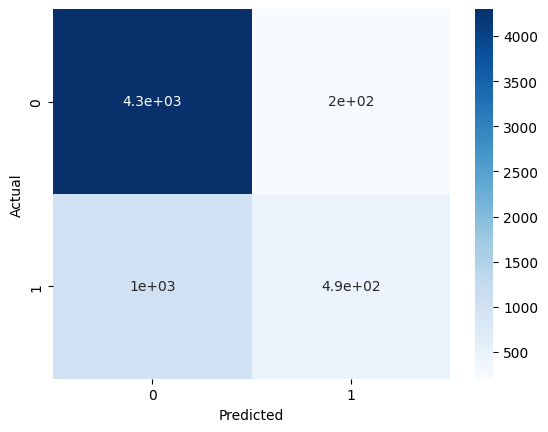

In [ ]:
# visualize the confusion matrix

import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Categorical Naive Bayes #

In [ ]:
# run the above cells first to load the data

# Identify numerical features
numerical_features = ['age', 'hours-per-week', 'capital-gain','capital-loss']

# Convert numerical features to categorical using equal frequency binning
for feature in numerical_features:
    data[feature + '_bin'] = pd.cut(data[feature], bins=4, labels=False)

# Drop original numerical columns and keep only the binned columns
data = data.drop(columns=numerical_features)

# List of categorical features (including binned columns)
categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income'] + [feature + '_bin' for feature in numerical_features]

# Encode categorical features using Label Encoding
le = LabelEncoder()
for feature in categorical_features:
    data[feature] = le.fit_transform(data[feature])

# Prepare features and target variable
X = data.drop('income', axis=1)
y = data['income']

In [ ]:
data.age_bin.value_counts()

age_bin
0    13738
1    12206
2     3888
3      330
Name: count, dtype: int64

In [ ]:
X

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,age_bin,hours-per-week_bin,capital-gain_bin,capital-loss_bin
0,5,9,4,0,1,4,1,38,1,1,0,0
1,4,9,2,3,0,4,1,38,1,0,0,0
2,2,11,0,5,1,4,1,38,1,1,0,0
3,2,1,2,5,0,2,1,38,1,1,0,0
4,2,9,2,9,5,2,0,4,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
32556,2,7,2,12,5,4,0,38,0,1,0,0
32557,2,11,2,6,0,4,1,38,1,1,0,0
32558,2,11,6,0,4,4,0,38,2,1,0,0
32559,2,11,4,0,3,4,1,38,0,0,0,0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Initialize and train the Categorical Naive Bayes model

from sklearn.naive_bayes import CategoricalNB

cnb = CategoricalNB()
cnb.fit(X_train, y_train)

# Predict and evaluate the Categorical Naive Bayes model
y_pred_cnb = cnb.predict(X_test)
y_pred_proba_cnb_width = cnb.predict_proba(X_test)[:, 1]
print("Categorical Naive Bayes Model")
print(f"Accuracy: {accuracy_score(y_test, y_pred_cnb)}")
print(confusion_matrix(y_test, y_pred_cnb))
print(classification_report(y_test, y_pred_cnb))



Categorical Naive Bayes Model
Accuracy: 0.8022542681916128
[[3699  804]
 [ 389 1141]]
              precision    recall  f1-score   support

           0       0.90      0.82      0.86      4503
           1       0.59      0.75      0.66      1530

    accuracy                           0.80      6033
   macro avg       0.75      0.78      0.76      6033
weighted avg       0.82      0.80      0.81      6033



In [ ]:
# Convert numerical features to categorical using equal frequency binning

# run the first cells to load the data

# run the above cells first to load the data

# Identify numerical features
numerical_features = ['age', 'hours-per-week', 'capital-gain','capital-loss']

# Convert numerical features to categorical using equal frequency binning
for feature in numerical_features:
    data[feature + '_bin'] = pd.qcut(data[feature], q=4, labels=False, duplicates= 'drop')

# Drop original numerical columns and keep only the binned columns
data = data.drop(columns=numerical_features)

# List of categorical features (including binned columns)
categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income'] + [feature + '_bin' for feature in numerical_features]

# Encode categorical features using Label Encoding
le = LabelEncoder()
for feature in categorical_features:
    data[feature] = le.fit_transform(data[feature])

# Prepare features and target variable
X = data.drop('income', axis=1)
y = data['income']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
data.age_bin.value_counts()

age_bin
0    8010
1    7408
2    7399
3    7345
Name: count, dtype: int64

In [ ]:
# Initialize and train the Categorical Naive Bayes model
cnb1 = CategoricalNB()
cnb1.fit(X_train, y_train)

# Predict and evaluate the Categorical Naive Bayes model
y_pred_cnb = cnb1.predict(X_test)
y_pred_proba_cnb_depth = cnb1.predict_proba(X_test)[:, 1]
print("Categorical Naive Bayes Model with equal depth binning")
print(f"Accuracy: {accuracy_score(y_test, y_pred_cnb)}")
print(confusion_matrix(y_test, y_pred_cnb))
print(classification_report(y_test, y_pred_cnb))


Categorical Naive Bayes Model with equal depth binning
Accuracy: 0.7987734128957401
[[3673  830]
 [ 384 1146]]
              precision    recall  f1-score   support

           0       0.91      0.82      0.86      4503
           1       0.58      0.75      0.65      1530

    accuracy                           0.80      6033
   macro avg       0.74      0.78      0.76      6033
weighted avg       0.82      0.80      0.81      6033



# Hybrid Model #

In [ ]:
# run the first cells to load the dataset


# Identify numerical and categorical features
numerical_features = ['age', 'hours-per-week', 'capital-gain','capital-loss']
categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']

# Encode categorical features using Label Encoding
le = LabelEncoder()
for feature in categorical_features + ['income']:
    data[feature] = le.fit_transform(data[feature])

# Prepare features and target variable
X_num = data[numerical_features]
X_cat = data[categorical_features]
y = data['income']

# Split the data
X_num_train, X_num_test, X_cat_train, X_cat_test, y_train, y_test = train_test_split(X_num, X_cat, y, test_size=0.2, random_state=42)

# Initialize and train the Gaussian Naive Bayes model
gnb = GaussianNB()
gnb.fit(X_num_train, y_train)

# Initialize and train the Categorical Naive Bayes model
cnb = CategoricalNB()
cnb.fit(X_cat_train, y_train)

# Predict with both models
y_pred_prob_gnb = gnb.predict_proba(X_num_test)
y_pred_proba_gnb = gnb.predict_proba(X_num_test)[:, 1]
y_pred_prob_cnb = cnb.predict_proba(X_cat_test)
y_pred_proba_cnb = cnb.predict_proba(X_cat_test)[:, 1]

# Combine predictions by averaging probabilities
combined_pred_prob = (y_pred_prob_gnb + y_pred_prob_cnb) / 2
y_pred_hybrid = np.argmax(combined_pred_prob, axis=1)

y_pred_proba_combined = (y_pred_proba_gnb + y_pred_proba_cnb) / 2
y_pred_proba_hybrid = y_pred_proba_combined

# accuracy
accuracy = accuracy_score(y_test, y_pred_hybrid)
print("Accuracy:", accuracy)

# confusion matrix
cm = confusion_matrix(y_test, y_pred_hybrid)
print(cm)

# calculate the classification report
report = classification_report(y_test, y_pred_hybrid)
print(report)


Accuracy: 0.991546494281452
[[4462   41]
 [  10 1520]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4503
           1       0.97      0.99      0.98      1530

    accuracy                           0.99      6033
   macro avg       0.99      0.99      0.99      6033
weighted avg       0.99      0.99      0.99      6033



[[4462   41]
 [  10 1520]]


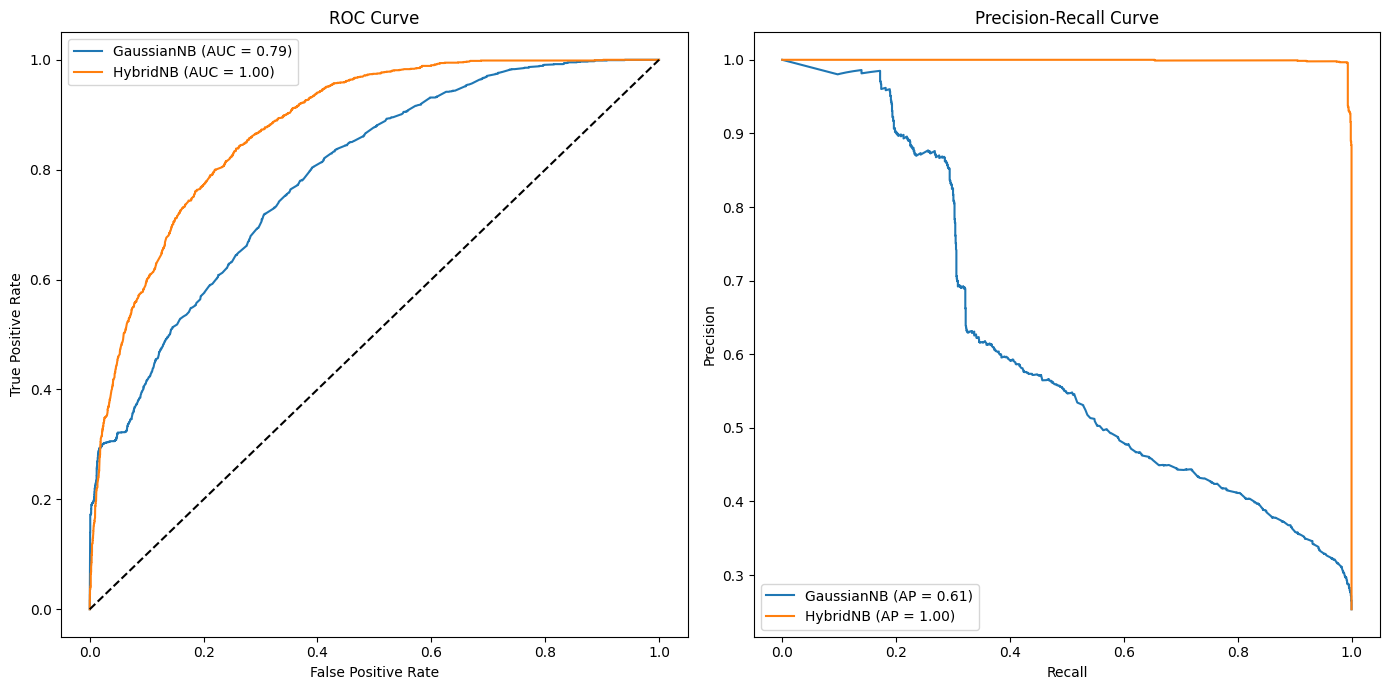

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Plotting ROC Curve
fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_pred_proba_gnb)
fpr_cnb, tpr_cnb, _ = roc_curve(y_test, y_pred_proba_cnb_width)

plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
plt.plot(fpr_gnb, tpr_gnb, label=f'GaussianNB (AUC = {roc_auc_score(y_test, y_pred_proba_gnb):.2f})')
plt.plot(fpr_cnb, tpr_cnb, label=f'HybridNB (AUC = {roc_auc_score(y_test, y_pred_proba_hybrid):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

# Plotting Precision-Recall Curve
precision_gnb, recall_gnb, _ = precision_recall_curve(y_test, y_pred_proba_gnb)
precision_cnb, recall_cnb, _ = precision_recall_curve(y_test, y_pred_proba_hybrid)

plt.subplot(1, 2, 2)
plt.plot(recall_gnb, precision_gnb, label=f'GaussianNB (AP = {average_precision_score(y_test, y_pred_proba_gnb):.2f})')
plt.plot(recall_cnb, precision_cnb, label=f'HybridNB (AP = {average_precision_score(y_test, y_pred_proba_hybrid):.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.tight_layout()
plt.show()


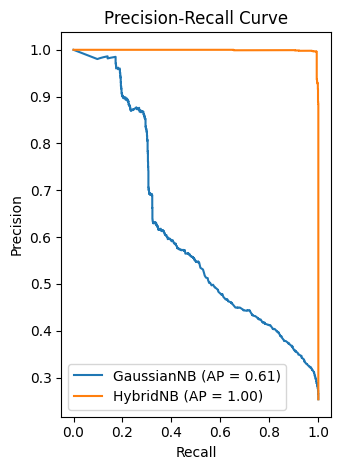

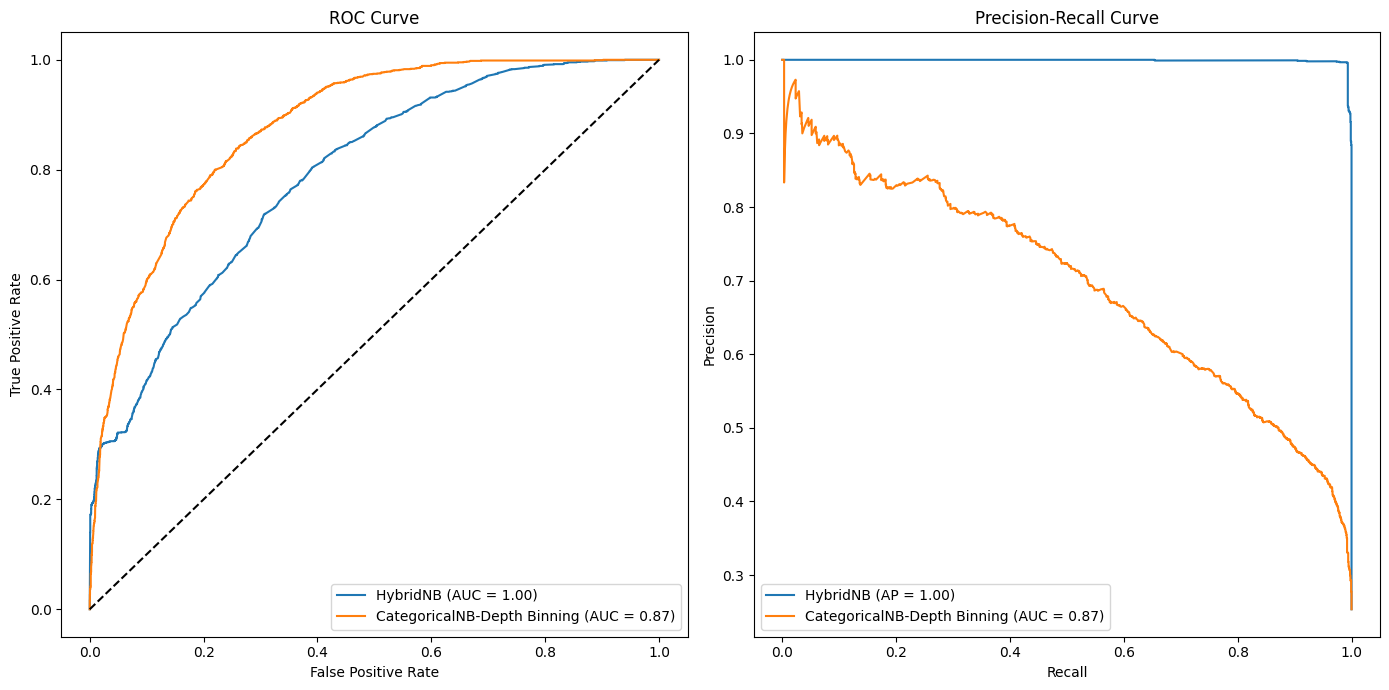

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Plotting ROC Curve
fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_pred_proba_gnb)
fpr_cnb, tpr_cnb, _ = roc_curve(y_test, y_pred_proba_cnb_width)

plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
plt.plot(fpr_gnb, tpr_gnb, label=f'HybridNB (AUC = {roc_auc_score(y_test, y_pred_proba_hybrid):.2f})')
plt.plot(fpr_cnb, tpr_cnb, label=f'CategoricalNB-Depth Binning (AUC = {roc_auc_score(y_test, y_pred_proba_cnb_depth):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

# Plotting Precision-Recall Curve
precision_gnb, recall_gnb, _ = precision_recall_curve(y_test, y_pred_proba_hybrid)
precision_cnb, recall_cnb, _ = precision_recall_curve(y_test, y_pred_proba_cnb_depth)

plt.subplot(1, 2, 2)
plt.plot(recall_gnb, precision_gnb, label=f'HybridNB (AP = {average_precision_score(y_test, y_pred_proba_hybrid):.2f})')
plt.plot(recall_cnb, precision_cnb, label=f'CategoricalNB-Depth Binning (AUC = {roc_auc_score(y_test, y_pred_proba_cnb_depth):.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.tight_layout()
plt.show()


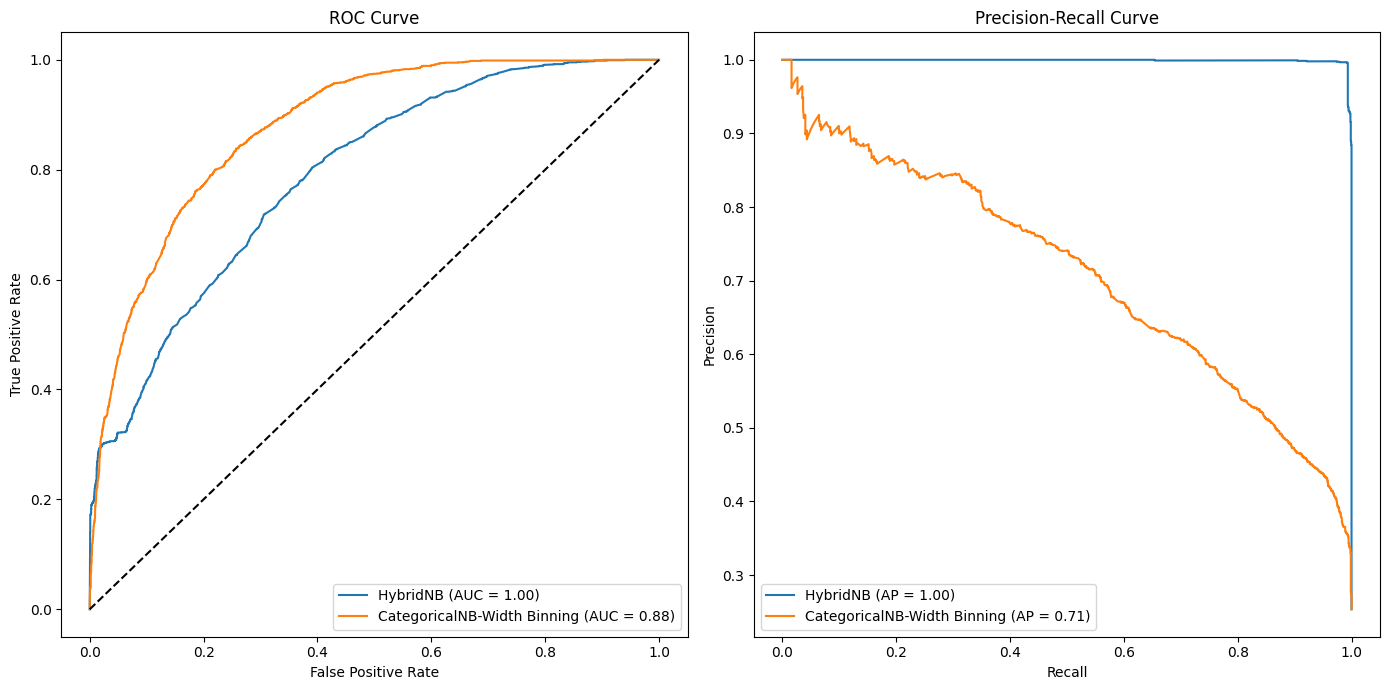

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Plotting ROC Curve
fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_pred_proba_gnb)
fpr_cnb, tpr_cnb, _ = roc_curve(y_test, y_pred_proba_cnb_width)

plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
plt.plot(fpr_gnb, tpr_gnb, label=f'HybridNB (AUC = {roc_auc_score(y_test, y_pred_proba_hybrid):.2f})')
plt.plot(fpr_cnb, tpr_cnb, label=f'CategoricalNB-Width Binning (AUC = {roc_auc_score(y_test, y_pred_proba_cnb_width):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

# Plotting Precision-Recall Curve
precision_gnb, recall_gnb, _ = precision_recall_curve(y_test, y_pred_proba_hybrid)
precision_cnb, recall_cnb, _ = precision_recall_curve(y_test, y_pred_proba_cnb_width)

plt.subplot(1, 2, 2)
plt.plot(recall_gnb, precision_gnb, label=f'HybridNB (AP = {average_precision_score(y_test, y_pred_proba_hybrid):.2f})')
plt.plot(recall_cnb, precision_cnb, label=f'CategoricalNB-Width Binning (AP = {average_precision_score(y_test, y_pred_proba_cnb_width):.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.tight_layout()
plt.show()
